In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import os

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2026-03-31 02:45:41.003062: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774925141.188357      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774925141.243930      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774925141.672266      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774925141.672308      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774925141.672311      55 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Cell 2: Define paths (FIXED)

INPUT_DIR = '/kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images'

TRAIN_PATH = os.path.join(INPUT_DIR, 'train')
TEST_PATH  = os.path.join(INPUT_DIR, 'test')
VAL_PATH   = os.path.join(INPUT_DIR, 'validation')  # will be created

print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

print("\nCheck directories:")
print("Train exists:", os.path.exists(TRAIN_PATH))
print("Test exists:", os.path.exists(TEST_PATH))

Train path: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/train
Test path: /kaggle/input/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images/test

Check directories:
Train exists: True
Test exists: True


In [3]:
# Cell 3: Create validation set (COPY, not move)

import shutil

WORKING_DIR = '/kaggle/working/cifake'
TRAIN_WORK = os.path.join(WORKING_DIR, 'train')
VAL_WORK   = os.path.join(WORKING_DIR, 'validation')
TEST_WORK  = os.path.join(WORKING_DIR, 'test')

# Copy dataset to working directory (writeable)
if not os.path.exists(WORKING_DIR):
    print("Copying dataset to working directory...")
    shutil.copytree(TRAIN_PATH, TRAIN_WORK)
    shutil.copytree(TEST_PATH, TEST_WORK)

# Create validation split
if not os.path.exists(VAL_WORK):
    os.makedirs(VAL_WORK, exist_ok=True)

    for class_name in os.listdir(TRAIN_WORK):
        class_path = os.path.join(TRAIN_WORK, class_name)
        val_class_path = os.path.join(VAL_WORK, class_name)

        os.makedirs(val_class_path, exist_ok=True)

        images = os.listdir(class_path)
        val_count = int(len(images) * 0.1)

        for img in images[:val_count]:
            src = os.path.join(class_path, img)
            dst = os.path.join(val_class_path, img)
            shutil.move(src, dst)

        print(f"{class_name}: moved {val_count} images")

print("Validation ready!")

# Update paths to working directory
TRAIN_PATH = TRAIN_WORK
VAL_PATH   = VAL_WORK
TEST_PATH  = TEST_WORK

Copying dataset to working directory...
REAL: moved 5000 images
FAKE: moved 5000 images
Validation ready!


In [4]:
# Cell 4: Data Generators

IMG_SIZE = (299, 299)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = val_datagen.flow_from_directory(
    TEST_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 90000 images belonging to 2 classes.
Found 10000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [5]:
# Cell 5: Build the Inception-based model
def build_inception_model(input_shape=(299, 299, 3), num_classes=1):
    """
    Build a model based on InceptionV3 architecture
    """
    
    # Load pre-trained InceptionV3 without top layers
    base_model = InceptionV3(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    
    # Freeze base model layers initially
    base_model.trainable = False
    
    # Add custom layers on top
    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='sigmoid')(x)
    
    model = tf.keras.Model(inputs, outputs)
    
    return model, base_model

print("Building model...")
model, base_model = build_inception_model()
model.summary()

Building model...


I0000 00:00:1774926144.743427      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 8, 8, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,991,649 (87.71 MB)

 Trainable params: 1,184,769 (4.52 MB)

 Non-trainable params: 21,806,880 (83.19 MB)

In [6]:
# Cell 6: Compile model and set up callbacks
# Compile model
initial_learning_rate = 0.001
model.compile(
    optimizer=Adam(learning_rate=initial_learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

# Callbacks
callbacks = [
    ModelCheckpoint(
        '/kaggle/working/best_inception_model.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("Model compiled successfully!")
print(f"Initial learning rate: {initial_learning_rate}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Image size: {IMG_SIZE}")

Model compiled successfully!
Initial learning rate: 0.001
Batch size: 32
Image size: (299, 299)


In [7]:
# Cell 7: Phase 1 - Train only the top layers with enhanced saving
print("\n" + "="*60)
print("PHASE 1: Training Top Layers")
print("="*60)

EPOCHS_PHASE1 = 10

# Create a unique timestamp for model versions
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Enhanced callbacks with multiple save formats
callbacks_phase1 = [
    # Save best model in H5 format
    ModelCheckpoint(
        '/kaggle/working/best_inception_model_phase1.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    # Save best model in new Keras format
    ModelCheckpoint(
        '/kaggle/working/best_inception_model_phase1.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    # Save checkpoint every epoch
    ModelCheckpoint(
        f'/kaggle/working/checkpoint_phase1_epoch_{{epoch:02d}}_{timestamp}.h5',
        save_weights_only=False,
        verbose=0
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history1 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS_PHASE1,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=callbacks_phase1,
    verbose=1
)

print("\n✅ Phase 1 completed!")
print(f"Best validation accuracy: {max(history1.history['val_accuracy']):.4f}")

# Save Phase 1 model explicitly
model.save('/kaggle/working/phase1_final_model.h5')
model.save('/kaggle/working/phase1_final_model.keras')
print("✅ Phase 1 final model saved successfully!")

# Save training history
history1_df = pd.DataFrame(history1.history)
history1_df.to_csv('/kaggle/working/phase1_training_history.csv', index=False)
print("✅ Phase 1 training history saved!")


PHASE 1: Training Top Layers


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1774926257.109750     157 service.cc:152] XLA service 0x7c64c4003320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774926257.109792     157 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774926259.637001     157 cuda_dnn.cc:529] Loaded cuDNN version 91002


   2/2812 ━━━━━━━━━━━━━━━━━━━━ 3:42 79ms/step - accuracy: 0.5703 - auc: 0.5370 - loss: 0.9400 - precision: 0.5131 - recall: 0.5536   

...


Epoch 9: val_accuracy improved from 0.89714 to 0.90445, saving model to /kaggle/working/best_inception_model_phase1.keras


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 1609s 572ms/step - accuracy: 0.8694 - auc: 0.9415 - loss: 0.3139 - precision: 0.8704 - recall: 0.8665 - val_accuracy: 0.9044 - val_auc: 0.9668 - val_loss: 0.2377 - val_precision: 0.9114 - val_recall: 0.8961 - learning_rate: 0.0010
Epoch 10/10
   1/2812 ━━━━━━━━━━━━━━━━━━━━ 3:10 68ms/step - accuracy: 0.9375 - auc: 0.9922 - loss: 0.1977 - precision: 0.8824 - recall: 1.0000
Epoch 10: val_accuracy improved from 0.90445 to 0.90465, saving model to /kaggle/working/best_inception_model_phase1.h5



Epoch 10: val_accuracy improved from 0.90445 to 0.90465, saving model to /kaggle/working/best_inception_model_phase1.keras


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 28s 10ms/step - accuracy: 0.9375 - auc: 0.9922 - loss: 0.1977 - precision: 0.8824 - recall: 1.0000 - val_accuracy: 0.9046 - val_auc: 0.9670 - val_loss: 0.2374 - val_precision: 0.9111 - val_recall: 0.8969 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.



✅ Phase 1 completed!
Best validation accuracy: 0.9046
✅ Phase 1 final model saved successfully!
✅ Phase 1 training history saved!


In [8]:
# Cell 8: Phase 2 - Fine-tune the entire model with enhanced saving
print("\n" + "="*60)
print("PHASE 2: Fine-tuning Entire Model")
print("="*60)
print(f"Starting from Phase 1 best validation accuracy: {max(history1.history['val_accuracy']):.4f}")

# Unfreeze the base model
base_model.trainable = True

# Freeze first 100 layers for better fine-tuning
for i, layer in enumerate(base_model.layers[:100]):
    layer.trainable = False

print(f"Trainable layers: {sum(1 for layer in model.layers if layer.trainable)}")
print(f"Non-trainable layers: {sum(1 for layer in model.layers if not layer.trainable)}")

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=initial_learning_rate / 10),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

# Enhanced callbacks for Phase 2
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
callbacks_phase2 = [
    # Save best model in H5 format
    ModelCheckpoint(
        '/kaggle/working/best_inception_model_phase2.h5',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    ),
    # Save best model in Keras format
    ModelCheckpoint(
        '/kaggle/working/best_inception_model_phase2.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    # Save checkpoint every epoch
    ModelCheckpoint(
        f'/kaggle/working/checkpoint_phase2_epoch_{{epoch:02d}}_{timestamp}.h5',
        save_weights_only=False,
        verbose=0
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]

EPOCHS_PHASE2 = 15  # Reduced for faster training

print(f"\nStarting Phase 2 training for {EPOCHS_PHASE2} epochs...")
print("="*60)

history2 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=EPOCHS_PHASE2,
    validation_data=val_generator,
    validation_steps=val_generator.samples // val_generator.batch_size,
    callbacks=callbacks_phase2,
    verbose=1
)

print("\n✅ Phase 2 completed!")
print(f"Best validation accuracy: {max(history2.history['val_accuracy']):.4f}")

# Save Phase 2 final model
model.save('/kaggle/working/phase2_final_model.h5')
model.save('/kaggle/working/phase2_final_model.keras')
print("✅ Phase 2 final model saved successfully!")

# Save training history
history2_df = pd.DataFrame(history2.history)
history2_df.to_csv('/kaggle/working/phase2_training_history.csv', index=False)
print("✅ Phase 2 training history saved!")


PHASE 2: Fine-tuning Entire Model
Starting from Phase 1 best validation accuracy: 0.9046
Trainable layers: 9
Non-trainable layers: 0

Starting Phase 2 training for 15 epochs...
Epoch 1/15
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.9068 - auc_1: 0.9645 - loss: 0.2407 - precision_1: 0.9093 - recall_1: 0.9037
Epoch 1: val_accuracy improved from -inf to 0.95974, saving model to /kaggle/working/best_inception_model_phase2.h5



Epoch 1: val_accuracy improved from -inf to 0.95974, saving model to /kaggle/working/best_inception_model_phase2.keras


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 1739s 601ms/step - accuracy: 0.9068 - auc_1: 0.9645 - loss: 0.2407 - precision_1: 0.9093 - recall_1: 0.9037 - val_accuracy: 0.9597 - val_auc_1: 0.9927 - val_loss: 0.1080 - val_precision_1: 0.9588 - val_recall_1: 0.9607 - learning_rate: 1.0000e-04
Epoch 2/15
   1/2812 ━━━━━━━━━━━━━━━━━━━━ 7:28 160ms/step - accuracy: 0.9375 - auc_1: 0.9961 - loss: 0.1096 - precision_1: 0.9333 - recall_1: 0.9333
Epoch 2: val_accuracy did not improve from 0.95974

Epoch 2: val_accuracy did not improve from 0.95974


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 26s 9ms/step - accuracy: 0.9375 - auc_1: 0.9961 - loss: 0.1096 - precision_1: 0.9333 - recall_1: 0.9333 - val_accuracy: 0.9593 - val_auc_1: 0.9927 - val_loss: 0.1077 - val_precision_1: 0.9588 - val_recall_1: 0.9599 - learning_rate: 1.0000e-04
Epoch 3/15
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.9557 - auc_1: 0.9905 - loss: 0.1208 - precision_1: 0.9573 - recall_1: 0.9532
Epoch 3: val_accuracy improved from 0.95974 to 0.96805, saving model to /kaggle/working/best_inception_model_phase2.h5



Epoch 3: val_accuracy improved from 0.95974 to 0.96805, saving model to /kaggle/working/best_inception_model_phase2.keras


...


Epoch 13: val_accuracy improved from 0.97806 to 0.98458, saving model to /kaggle/working/best_inception_model_phase2.keras


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 1652s 588ms/step - accuracy: 0.9850 - auc_1: 0.9983 - loss: 0.0430 - precision_1: 0.9858 - recall_1: 0.9841 - val_accuracy: 0.9846 - val_auc_1: 0.9983 - val_loss: 0.0452 - val_precision_1: 0.9857 - val_recall_1: 0.9834 - learning_rate: 5.0000e-05
Epoch 14/15
   1/2812 ━━━━━━━━━━━━━━━━━━━━ 7:34 162ms/step - accuracy: 1.0000 - auc_1: 1.0000 - loss: 0.0035 - precision_1: 1.0000 - recall_1: 1.0000
Epoch 14: val_accuracy did not improve from 0.98458

Epoch 14: val_accuracy did not improve from 0.98458


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 1.0000 - auc_1: 1.0000 - loss: 0.0035 - precision_1: 1.0000 - recall_1: 1.0000 - val_accuracy: 0.9846 - val_auc_1: 0.9983 - val_loss: 0.0452 - val_precision_1: 0.9856 - val_recall_1: 0.9836 - learning_rate: 5.0000e-05
Epoch 15/15
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9883 - auc_1: 0.9990 - loss: 0.0330 - precision_1: 0.9886 - recall_1: 0.9879
Epoch 15: val_accuracy did not improve from 0.98458

Epoch 15: val_accuracy did not improve from 0.98458


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 1673s 595ms/step - accuracy: 0.9883 - auc_1: 0.9990 - loss: 0.0330 - precision_1: 0.9886 - recall_1: 0.9879 - val_accuracy: 0.9833 - val_auc_1: 0.9983 - val_loss: 0.0476 - val_precision_1: 0.9898 - val_recall_1: 0.9766 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 13.



✅ Phase 2 completed!
Best validation accuracy: 0.9846
✅ Phase 2 final model saved successfully!
✅ Phase 2 training history saved!


In [9]:
import os

working_dir = '/kaggle/working/'

print("="*60)
print("📁 FILES IN /kaggle/working/")
print("="*60)

files = os.listdir(working_dir)

if len(files) == 0:
    print("❌ No files found! Nothing was saved.")
else:
    for file in files:
        file_path = os.path.join(working_dir, file)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        print(f"✅ {file}  -->  {size_mb:.2f} MB")

print("\n" + "="*60)
print("🔍 CHECKING IMPORTANT MODEL FILES")
print("="*60)

important_files = [
    'final_inception_model.keras',
    'final_inception_model.h5',
    'phase2_final_model.keras',
    'phase2_final_model.h5',
    'best_inception_model_phase2.keras',
    'best_inception_model_phase2.h5'
]

for f in important_files:
    path = os.path.join(working_dir, f)
    if os.path.exists(path):
        print(f"✅ FOUND: {f}")
    else:
        print(f"❌ MISSING: {f}")

print("\n" + "="*60)
print("🧪 TEST LOADING MODEL (IMPORTANT)")
print("="*60)

from tensorflow.keras.models import load_model

# Try loading main model
model_path = '/kaggle/working/final_inception_model.keras'

if os.path.exists(model_path):
    try:
        model = load_model(model_path, compile=False)
        print("✅ Model loaded successfully!")
        print("📊 Model Summary:")
        model.summary()
    except Exception as e:
        print("❌ Error loading model:", e)
else:
    print("❌ final_inception_model.keras not found")

📁 FILES IN /kaggle/working/
✅ checkpoint_phase1_epoch_03_20260331_030407.h5  -->  97.36 MB
✅ phase1_training_history.csv  -->  0.00 MB
✅ checkpoint_phase2_epoch_15_20260331_052223.h5  -->  247.21 MB
✅ phase1_final_model.h5  -->  97.36 MB
✅ checkpoint_phase1_epoch_06_20260331_030407.h5  -->  97.36 MB
✅ checkpoint_phase2_epoch_08_20260331_052223.h5  -->  247.21 MB
✅ phase2_training_history.csv  -->  0.00 MB
✅ checkpoint_phase1_epoch_02_20260331_030407.h5  -->  97.36 MB
✅ phase1_final_model.keras  -->  97.81 MB
✅ cifake  -->  0.00 MB
✅ checkpoint_phase2_epoch_10_20260331_052223.h5  -->  247.21 MB
✅ checkpoint_phase2_epoch_03_20260331_052223.h5  -->  247.21 MB
✅ checkpoint_phase2_epoch_07_20260331_052223.h5  -->  247.21 MB
✅ phase2_final_model.keras  -->  247.64 MB
✅ checkpoint_phase2_epoch_09_20260331_052223.h5  -->  247.21 MB
✅ checkpoint_phase2_epoch_13_20260331_052223.h5  -->  247.21 MB
✅ best_inception_model_phase1.h5  -->  97.36 MB
✅ checkpoint_phase1_epoch_04_20260331_030407.h5  -->

In [11]:
# Cell 9: Combine histories and save final master model

import os
import pandas as pd
import tensorflow as tf

print("\n" + "="*60)
print("SAVING FINAL MASTER MODEL")
print("="*60)

# -------------------------------
# Combine histories (Phase 1 + Phase 2)
# -------------------------------
history = {}
for key in history1.history.keys():
    if key in history2.history:
        history[key] = history1.history[key] + history2.history[key]

print("✅ Combined training history")

# -------------------------------
# Load best model from Phase 2
# -------------------------------
best_model_path_h5 = '/kaggle/working/best_inception_model_phase2.h5'
best_model_path_keras = '/kaggle/working/best_inception_model_phase2.keras'

if os.path.exists(best_model_path_keras):
    final_model = tf.keras.models.load_model(best_model_path_keras, compile=False)
    print("✅ Loaded best Phase 2 model (.keras) as final model")
elif os.path.exists(best_model_path_h5):
    final_model = tf.keras.models.load_model(best_model_path_h5, compile=False)
    print("✅ Loaded best Phase 2 model (.h5) as final model")
else:
    final_model = model
    print("⚠️ Best model not found, using current model")

# -------------------------------
# Save final model in multiple formats
# -------------------------------
print("\n📁 Saving final models...")

# Recommended Keras format
final_model.save('/kaggle/working/final_inception_model.keras')
print("  ✓ final_inception_model.keras")

# Legacy H5 format
final_model.save('/kaggle/working/final_inception_model.h5')
print("  ✓ final_inception_model.h5")

# Save weights (FIXED filename)
final_model.save_weights('/kaggle/working/final_model.weights.h5')
print("  ✓ final_model.weights.h5")

# Save architecture
with open('/kaggle/working/model_architecture.json', 'w') as f:
    f.write(final_model.to_json())
print("  ✓ model_architecture.json")

# Save combined training history
history_df = pd.DataFrame(history)
history_df.to_csv('/kaggle/working/combined_training_history.csv', index=False)
print("  ✓ combined_training_history.csv")

# -------------------------------
# Print improvement summary
# -------------------------------
print("\n" + "="*60)
print("TRAINING IMPROVEMENT SUMMARY")
print("="*60)

phase1_best = max(history1.history['val_accuracy'])
phase2_best = max(history2.history['val_accuracy'])

print(f"Phase 1 - Best Validation Accuracy: {phase1_best:.4f}")
print(f"Phase 2 - Best Validation Accuracy: {phase2_best:.4f}")

if phase2_best > phase1_best:
    improvement = phase2_best - phase1_best
    print(f"Improvement: +{improvement:.4f} ({improvement*100:.2f}%)")
else:
    print("No improvement in validation accuracy")

# -------------------------------
# Verify saved files
# -------------------------------
print("\n" + "="*60)
print("VERIFYING SAVED FILES")
print("="*60)

files = os.listdir('/kaggle/working/')
for file in files:
    print(f"✅ {file}")

print("\n🎉 All models and artifacts saved successfully!")


SAVING FINAL MASTER MODEL
✅ Combined training history
✅ Loaded best Phase 2 model (.keras) as final model

📁 Saving final models...


  ✓ final_inception_model.keras
  ✓ final_inception_model.h5
  ✓ final_model.weights.h5
  ✓ model_architecture.json
  ✓ combined_training_history.csv

TRAINING IMPROVEMENT SUMMARY
Phase 1 - Best Validation Accuracy: 0.9046
Phase 2 - Best Validation Accuracy: 0.9846
Improvement: +0.0799 (7.99%)

VERIFYING SAVED FILES
✅ checkpoint_phase1_epoch_03_20260331_030407.h5
✅ phase1_training_history.csv
✅ checkpoint_phase2_epoch_15_20260331_052223.h5
✅ final_inception_model.keras
✅ phase1_final_model.h5
✅ checkpoint_phase1_epoch_06_20260331_030407.h5
✅ checkpoint_phase2_epoch_08_20260331_052223.h5
✅ phase2_training_history.csv
✅ checkpoint_phase1_epoch_02_20260331_030407.h5
✅ phase1_final_model.keras
✅ combined_training_history.csv
✅ cifake
✅ checkpoint_phase2_epoch_10_20260331_052223.h5
✅ final_model.weights.h5
✅ checkpoint_phase2_epoch_03_20260331_052223.h5
✅ checkpoint_phase2_epoch_07_20260331_052223.h5
✅ phase2_final_model.keras
✅ checkpoint_phase2_epoch_09_20260331_052223.h5
✅ checkpoint_pha

In [12]:
# Zip all important files into one archive

import os
import zipfile

zip_path = '/kaggle/working/final_models_backup.zip'

print("📦 Creating ZIP file...")

with zipfile.ZipFile(zip_path, 'w') as zipf:
    
    for root, dirs, files in os.walk('/kaggle/working/'):
        for file in files:
            
            # Skip unnecessary files
            if file.endswith(('.h5', '.keras', '.json', '.csv')):
                
                file_path = os.path.join(root, file)
                zipf.write(file_path, os.path.basename(file_path))
                print(f"✅ Added: {file}")

print("\n🎉 ZIP file created successfully!")
print(f"📁 Location: {zip_path}")

📦 Creating ZIP file...
✅ Added: checkpoint_phase1_epoch_03_20260331_030407.h5
✅ Added: phase1_training_history.csv
✅ Added: checkpoint_phase2_epoch_15_20260331_052223.h5
✅ Added: final_inception_model.keras
✅ Added: phase1_final_model.h5
✅ Added: checkpoint_phase1_epoch_06_20260331_030407.h5
✅ Added: checkpoint_phase2_epoch_08_20260331_052223.h5
✅ Added: phase2_training_history.csv
✅ Added: checkpoint_phase1_epoch_02_20260331_030407.h5
✅ Added: phase1_final_model.keras
✅ Added: combined_training_history.csv
✅ Added: checkpoint_phase2_epoch_10_20260331_052223.h5
✅ Added: final_model.weights.h5
✅ Added: checkpoint_phase2_epoch_03_20260331_052223.h5
✅ Added: checkpoint_phase2_epoch_07_20260331_052223.h5
✅ Added: phase2_final_model.keras
✅ Added: checkpoint_phase2_epoch_09_20260331_052223.h5
✅ Added: checkpoint_phase2_epoch_13_20260331_052223.h5
✅ Added: best_inception_model_phase1.h5
✅ Added: checkpoint_phase1_epoch_04_20260331_030407.h5
✅ Added: checkpoint_phase1_epoch_07_20260331_030407

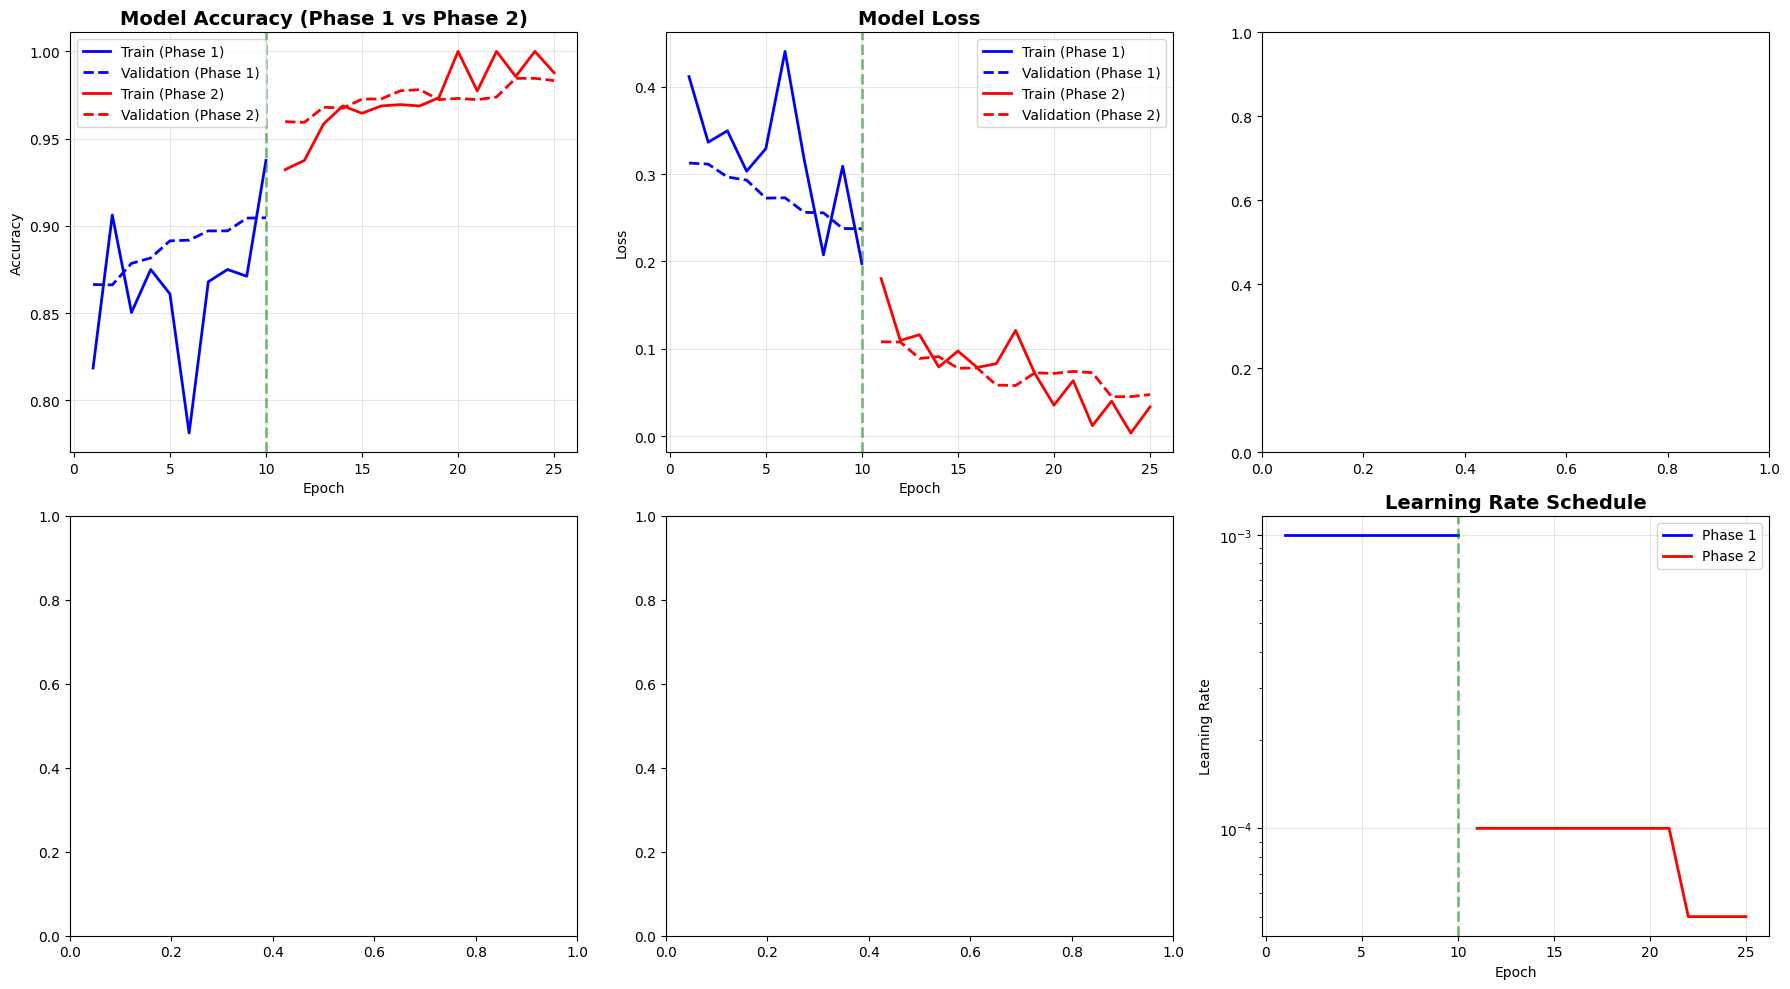

✅ Combined training history plot saved!


In [27]:
# Cell 10: Plot combined training history
def plot_training_history(history, history1, history2):
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Plot accuracy with phase separation
    epochs1 = range(1, len(history1.history['accuracy']) + 1)
    epochs2 = range(len(history1.history['accuracy']) + 1, 
                   len(history1.history['accuracy']) + len(history2.history['accuracy']) + 1)
    
    axes[0, 0].plot(epochs1, history1.history['accuracy'], 'b-', label='Train (Phase 1)', linewidth=2)
    axes[0, 0].plot(epochs1, history1.history['val_accuracy'], 'b--', label='Validation (Phase 1)', linewidth=2)
    axes[0, 0].plot(epochs2, history2.history['accuracy'], 'r-', label='Train (Phase 2)', linewidth=2)
    axes[0, 0].plot(epochs2, history2.history['val_accuracy'], 'r--', label='Validation (Phase 2)', linewidth=2)
    axes[0, 0].axvline(x=len(history1.history['accuracy']), color='g', linestyle='--', alpha=0.5, linewidth=2)
    axes[0, 0].set_title('Model Accuracy (Phase 1 vs Phase 2)', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot loss
    axes[0, 1].plot(epochs1, history1.history['loss'], 'b-', label='Train (Phase 1)', linewidth=2)
    axes[0, 1].plot(epochs1, history1.history['val_loss'], 'b--', label='Validation (Phase 1)', linewidth=2)
    axes[0, 1].plot(epochs2, history2.history['loss'], 'r-', label='Train (Phase 2)', linewidth=2)
    axes[0, 1].plot(epochs2, history2.history['val_loss'], 'r--', label='Validation (Phase 2)', linewidth=2)
    axes[0, 1].axvline(x=len(history1.history['loss']), color='g', linestyle='--', alpha=0.5, linewidth=2)
    axes[0, 1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot AUC
    if 'auc' in history1.history and 'auc' in history2.history:
        axes[0, 2].plot(epochs1, history1.history['auc'], 'b-', label='Train (Phase 1)', linewidth=2)
        axes[0, 2].plot(epochs1, history1.history['val_auc'], 'b--', label='Validation (Phase 1)', linewidth=2)
        axes[0, 2].plot(epochs2, history2.history['auc'], 'r-', label='Train (Phase 2)', linewidth=2)
        axes[0, 2].plot(epochs2, history2.history['val_auc'], 'r--', label='Validation (Phase 2)', linewidth=2)
        axes[0, 2].axvline(x=len(history1.history['auc']), color='g', linestyle='--', alpha=0.5, linewidth=2)
        axes[0, 2].set_title('AUC Score', fontsize=14, fontweight='bold')
        axes[0, 2].set_xlabel('Epoch')
        axes[0, 2].set_ylabel('AUC')
        axes[0, 2].legend()
        axes[0, 2].grid(True, alpha=0.3)
    
    # Plot Precision
    if 'precision' in history1.history and 'precision' in history2.history:
        axes[1, 0].plot(epochs1, history1.history['precision'], 'b-', label='Train (Phase 1)', linewidth=2)
        axes[1, 0].plot(epochs1, history1.history['val_precision'], 'b--', label='Validation (Phase 1)', linewidth=2)
        axes[1, 0].plot(epochs2, history2.history['precision'], 'r-', label='Train (Phase 2)', linewidth=2)
        axes[1, 0].plot(epochs2, history2.history['val_precision'], 'r--', label='Validation (Phase 2)', linewidth=2)
        axes[1, 0].axvline(x=len(history1.history['precision']), color='g', linestyle='--', alpha=0.5, linewidth=2)
        axes[1, 0].set_title('Precision', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('Precision')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
    
    # Plot Recall
    if 'recall' in history1.history and 'recall' in history2.history:
        axes[1, 1].plot(epochs1, history1.history['recall'], 'b-', label='Train (Phase 1)', linewidth=2)
        axes[1, 1].plot(epochs1, history1.history['val_recall'], 'b--', label='Validation (Phase 1)', linewidth=2)
        axes[1, 1].plot(epochs2, history2.history['recall'], 'r-', label='Train (Phase 2)', linewidth=2)
        axes[1, 1].plot(epochs2, history2.history['val_recall'], 'r--', label='Validation (Phase 2)', linewidth=2)
        axes[1, 1].axvline(x=len(history1.history['recall']), color='g', linestyle='--', alpha=0.5, linewidth=2)
        axes[1, 1].set_title('Recall', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Epoch')
        axes[1, 1].set_ylabel('Recall')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
    
    # Learning rate plot
    if 'learning_rate' in history1.history:
        axes[1, 2].plot(epochs1, history1.history['learning_rate'], 'b-', label='Phase 1', linewidth=2)
        if 'learning_rate' in history2.history:
            axes[1, 2].plot(epochs2, history2.history['learning_rate'], 'r-', label='Phase 2', linewidth=2)
        axes[1, 2].axvline(x=len(history1.history['learning_rate']), color='g', linestyle='--', alpha=0.5, linewidth=2)
        axes[1, 2].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
        axes[1, 2].set_xlabel('Epoch')
        axes[1, 2].set_ylabel('Learning Rate')
        axes[1, 2].set_yscale('log')
        axes[1, 2].legend()
        axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/kaggle/working/combined_training_history.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_training_history(history, history1, history2)
print("✅ Combined training history plot saved!")

In [29]:
# Cell 11: Evaluate final model on test set
print("\n" + "="*60)
print("EVALUATING FINAL MODEL ON TEST SET")
print("="*60)

import tensorflow as tf
import os
import pandas as pd

# Load the final model
final_model_path = '/kaggle/working/final_inception_model.h5'

if os.path.exists(final_model_path):
    final_model = tf.keras.models.load_model(final_model_path)
    print(f"✅ Loaded final model from: {final_model_path}")
    
    # 🔥 IMPORTANT: Compile again
    final_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',   # change if your task is different
        metrics=['accuracy']
    )
    
    print("✅ Model compiled successfully")

else:
    print("⚠️ Final model not found, using current model")
    final_model = model

# Evaluate
test_results = final_model.evaluate(test_generator, verbose=1)
metrics_names = final_model.metrics_names

print("\n📊 Final Test Results:")
print("-" * 50)
for name, value in zip(metrics_names, test_results):
    print(f"{name:20s}: {value:.4f}")

# Save test results
test_results_df = pd.DataFrame({
    'Metric': metrics_names,
    'Value': test_results
})
test_results_df.to_csv('/kaggle/working/final_test_results.csv', index=False)

print("\n✅ Test results saved to final_test_results.csv")


EVALUATING FINAL MODEL ON TEST SET


✅ Loaded final model from: /kaggle/working/final_inception_model.h5
✅ Model compiled successfully
625/625 ━━━━━━━━━━━━━━━━━━━━ 68s 96ms/step - accuracy: 0.9836 - loss: 0.0428

📊 Final Test Results:
--------------------------------------------------
loss                : 0.0439
compile_metrics     : 0.9826

✅ Test results saved to final_test_results.csv



DETAILED PREDICTIONS ANALYSIS
625/625 ━━━━━━━━━━━━━━━━━━━━ 55s 79ms/step

📈 Classification Report:
--------------------------------------------------
              precision    recall  f1-score   support

        FAKE       0.98      0.98      0.98     10000
        REAL       0.98      0.98      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000

✅ Classification report saved


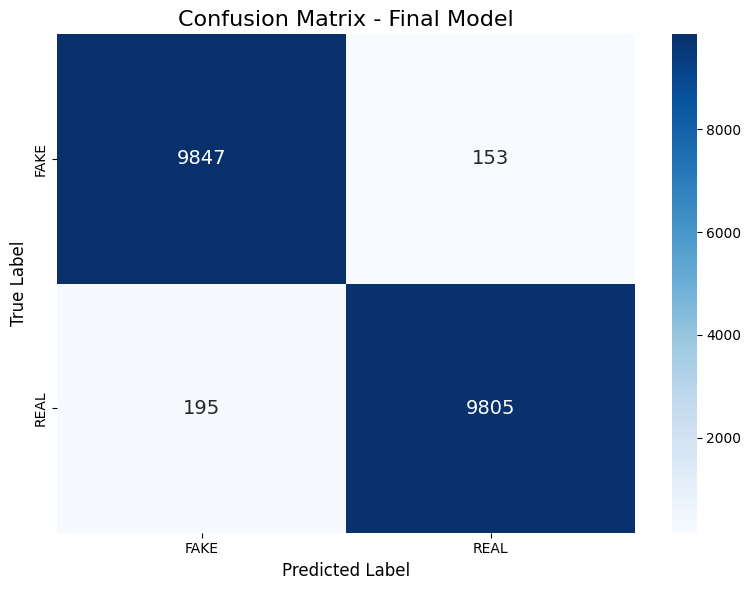

✅ Confusion matrix saved

📊 Detailed Metrics:
--------------------------------------------------
Overall Accuracy: 0.9826 (98.26%)
Sensitivity (Recall for REAL): 0.9805
Specificity (Recall for FAKE): 0.9847
False Positive Rate: 0.0153
False Negative Rate: 0.0195


In [30]:
# Cell 12: Generate detailed predictions and analysis
print("\n" + "="*60)
print("DETAILED PREDICTIONS ANALYSIS")
print("="*60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 🔥 IMPORTANT: Ensure no shuffling
test_generator.shuffle = False
test_generator.reset()

# Generate predictions
predictions = final_model.predict(test_generator, verbose=1)

# Handle prediction shape safely
if predictions.shape[-1] == 1:
    predicted_classes = (predictions > 0.5).astype(int).reshape(-1)
else:
    predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 🔥 Safety check
assert len(predicted_classes) == len(true_classes), "Mismatch in predictions and labels!"

# ================================
# 📈 Classification Report
# ================================
print("\n📈 Classification Report:")
print("-" * 50)

report = classification_report(
    true_classes, 
    predicted_classes, 
    target_names=class_names,
    output_dict=True
)

print(classification_report(true_classes, predicted_classes, target_names=class_names))

# Save classification report
report_df = pd.DataFrame(report).transpose()
report_df.to_csv('/kaggle/working/classification_report.csv')
print("✅ Classification report saved")

# ================================
# 📊 Confusion Matrix
# ================================
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    annot_kws={'size': 14}
)

plt.title('Confusion Matrix - Final Model', fontsize=16)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()

plt.savefig('/kaggle/working/final_confusion_matrix.png', dpi=300)
plt.show()

print("✅ Confusion matrix saved")

# ================================
# 📊 Additional Metrics
# ================================
accuracy = accuracy_score(true_classes, predicted_classes)

# Safe extraction
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print("\n📊 Detailed Metrics:")
    print("-" * 50)
    print(f"Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Sensitivity (Recall for {class_names[1]}): {sensitivity:.4f}")
    print(f"Specificity (Recall for {class_names[0]}): {specificity:.4f}")
    print(f"False Positive Rate: {fpr:.4f}")
    print(f"False Negative Rate: {fnr:.4f}")
else:
    print("\n⚠️ Not a binary classification confusion matrix")